<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# Evaluating Random Forest Performance
Estimated time needed: **30** minutes
    

## Objectives


After completing this lab, you will be able to:

* Implement and evaluate the performance of random forest regression models on real-world data
* Interpret various evaluation metrics and visualizations
* Describe the feature importances for a regression model

# 랜덤 포레스트 성능 평가
소요 시간: **30**분

## 목표

이 실습을 완료하면 다음을 수행할 수 있습니다.

* 실제 데이터에 대해 랜덤 포레스트 회귀 모델을 구현하고 성능을 평가할 수 있습니다.
* 다양한 평가 지표 및 시각화를 해석할 수 있습니다.
* 회귀 모델의 특징 중요도를 설명할 수 있습니다.

## Introduction
In this lab, you will:
- Use the California Housing data set included in scikit-learn to predict the median house price based on various attributes
- Create a random forest regression model and evaluate its performance
- Investigate the feature importances for the model 


Your goal in this lab is **not** to find the best regressor - it is primarily intended for you to practice interpreting modelling results in the context of a real-world problem.

## 소개
이 실습에서는 다음을 수행합니다.
- scikit-learn에 포함된 캘리포니아 주택 데이터 세트를 사용하여 다양한 속성을 기반으로 중간 주택 가격을 예측합니다.
- 랜덤 포레스트 회귀 모델을 생성하고 성능을 평가합니다.
- 모델의 특징 중요도를 분석합니다.

이 실습의 목표는 최적의 회귀 모델을 찾는 것이 아니라, 실제 문제 상황에서 모델링 결과를 해석하는 연습을 하는 것입니다.

Before you start, make sure that all the required libraries are installed. Execute the cell below for the same.


In [1]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3
!pip install scipy==1.14.1


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


## Import the required libraries


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import skew

### Load the California Housing data set


In [3]:
# Load the dataset
data = fetch_california_housing()
X, y = data.data, data.target

### Print the description of the California Housing data set


In [4]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

### Exercise 1. Split the data into training and testing sets
Reserve 20% of the data for evaluation


In [6]:
# Enter your code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



<details><summary>Click here for the solution</summary>

```python
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

```

</details>


## Explore the training data

## 훈련 데이터 탐색

In [10]:
eda = pd.DataFrame(data=X_train) #numpy 배열(X_train)을 pandas DataFrame으로 변환
eda.columns = data.feature_names
eda['MedHouseVal'] = y_train # 타겟(집값)을 새 컬럼으로 추가
eda.describe() # 각 컬럼의 기술통계 출력

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290,2.071947
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654,1.156226
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000,0.149990
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000,1.198000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000,1.798500
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000,2.651250
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Exercise 2. What range are most of the median house prices valued at?

### 연습문제 2. 대부분의 주택 중간 가격은 어떤 범위에 속합니까?



In [19]:
#### Please enter your descriptive answer here and change the cell type to "Markdown" for formatting.
eda.describe()['MedHouseVal']

count    16512.000000
mean         2.071947
std          1.156226
min          0.149990
25%          1.198000
50%          1.798500
75%          2.651250
max          5.000010
Name: MedHouseVal, dtype: float64

<details><summary>Click here for the solution</summary>
Considering the 25th to the 75th percentile range, most of the median house prices fall within \$119,300 and \$265,000.

</details>


### How are the median house prices distributed?


Text(0, 0.5, 'Frequency')

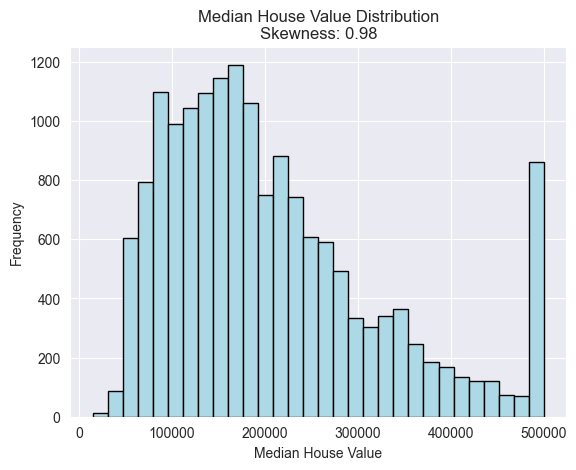

In [11]:
# Plot the distribution
plt.hist(1e5*y_train, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Median House Value Distribution\nSkewness: {skew(y_train):.2f}')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

Evidently the distribution is skewed and there are quite a few clipped values at around $500,000. 


### Model fitting and prediction
Let's fit a random forest regression model to the data and use it to make median house price predicions.
Use the default parameters, which includes using 100 base estimators, or regression trees.

### 모델 적합 및 예측
랜덤 포레스트 회귀 모델을 데이터에 적합시키고 이를 사용하여 중간 주택 가격을 예측해 보겠습니다.
기본 매개변수를 사용합니다. 여기에는 100개의 기본 추정기(회귀 트리)를 사용하는 것이 포함됩니다.

In [22]:
# Initialize and fit the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42) # n_estimators=100: 결정 트리 100개를 만듦
rf_regressor.fit(X_train, y_train) #100개의 트리가 각각 학습됨

# Predict on test set
y_pred_test = rf_regressor.predict(X_test) # 변수 중요도 확인
print(y_pred_test)

[0.50871   0.74412   4.9150872 ... 4.839239  0.71882   1.64662  ]


### Estimate out-of-sample MAE, MSE, RMSE, and R²


In [23]:
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = root_mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.3277
Mean Squared Error (MSE): 0.2559
Root Mean Squared Error (RMSE): 0.5058
R² Score: 0.8047


### Exercise 3. What do these statistics mean to you?
How comfortable could you be with stopping here and communicating the results to the C-suite?

### 연습 3. 이 통계 자료는 당신에게 어떤 의미가 있습니까?
여기서 분석을 중단하고 결과를 최고 경영진에게 전달하는 것에 대해 얼마나 편안하게 생각하십니까?

In [ ]:
#### Please enter your descriptive answer here and change the cell type to "Markdown" for formatting.


<details><summary>Click here for the solution</summary>
<p>The mean absolute error is $33,220.</p>

<p>So, on average, predicted median house prices are off by \$33k.</p>
Mean squared error is less intuitive to interpret, but is usually what is being minimized by the model fit. 

On the other hand, taking the square root of MSE yields a dollar value, here RMSE = \$50,630.

An R-squared score of 0.80 is not considered very high. It means the model explains about %80 of the variance in median house prices, although this interpretation can be misleading for compex data with nonlinear relationships, skewed values, and outliers. R-squard can still be useful for comparing models though.

These statistics alone don't explain any details about the performance of the model. 
For example, where did the model do well or poorly? 

We aren't done yet!</details>

<세부 정보><요약>해결 방법을 보려면 여기를 클릭하세요</요약>
<p>평균 절대 오차는 33,220달러입니다.</p>

<p>따라서 평균적으로 예측된 ​​중간 주택 가격은 33,000달러의 오차가 있습니다.</p>
평균 제곱 오차(MSE)는 직관적으로 해석하기는 어렵지만, 일반적으로 모델 적합 과정에서 최소화되는 값입니다.

반면에 MSE의 제곱근을 취하면 달러 값이 나오는데, 여기서는 RMSE = 50,630달러입니다.

R 제곱 값 0.80은 그다지 높은 값으로 간주되지 않습니다. 이는 모델이 중간 주택 가격 변동의 약 80%를 설명한다는 의미이지만, 비선형 관계, 왜곡된 값, 이상치가 있는 복잡한 데이터의 경우 이러한 해석이 오해의 소지가 있을 수 있습니다. 하지만 R 제곱 값은 모델을 비교하는 데 여전히 유용할 수 있습니다.

이러한 통계만으로는 모델 성능에 대한 자세한 정보를 설명할 수 없습니다.

예를 들어, 모델이 어떤 부분에서 잘했거나 못했나요?

아직 끝나지 않았습니다!</details>


### Plot Actual vs Predicted values


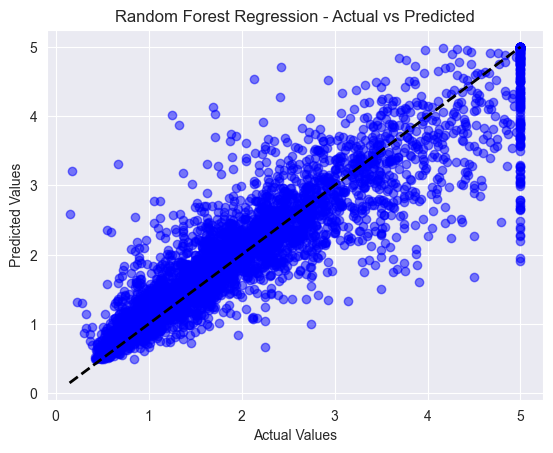

In [24]:
plt.scatter(y_test, y_pred_test, alpha=0.5, color="blue") #X축 실제 집 값 #Y축 예측 값
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) #  점선으로 대각선 생성
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression - Actual vs Predicted")
plt.show()

### Exercise 4. Plot the histogram of the residual errors (dollars)
Also, print the mean and standard deviation of the residuals.
Check for any patterns.


### 연습문제 4. 잔차 오차(달러)의 히스토그램을 그리시오.
또한, 잔차의 평균과 표준편차를 출력하시오.
패턴이 있는지 확인하시오.

Average error = 0
Standard deviation of error = 0


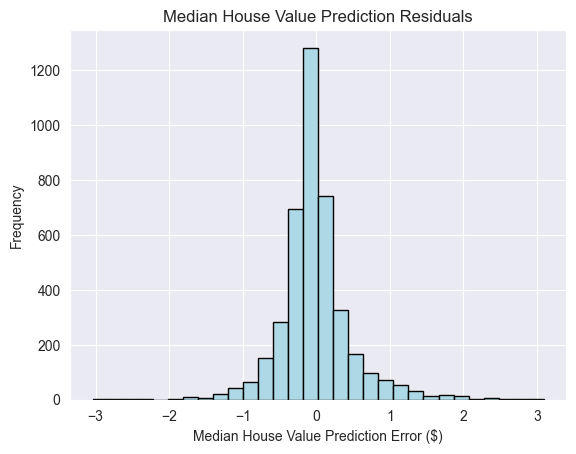

In [25]:
# Enter your code here
residuals = (y_test - y_pred_test)
plt.hist(residuals, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Median House Value Prediction Residuals')
plt.xlabel('Median House Value Prediction Error ($)')
plt.ylabel('Frequency')
print('Average error = ' + str(int(np.mean(residuals))))
print('Standard deviation of error = ' + str(int(np.std(residuals))))


<details><summary>Click here for the solution</summary>
    
```python
    
# Calculate the residual errors
residuals = 1e5*(y_test - y_pred_test)

# Plot the histogram of the residuals
plt.hist(residuals, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Median House Value Prediction Residuals')
plt.xlabel('Median House Value Prediction Error ($)')
plt.ylabel('Frequency')
print('Average error = ' + str(int(np.mean(residuals))))
print('Standard deviation of error = ' + str(int(np.std(residuals))))
```


The residuals are normally distributed with a very small average error and a standard deviation of about \$50,000.

잔차는 평균 오차가 매우 작고 표준 편차가 약 50,000달러인 정규 분포를 따릅니다.

### Exercise 5. Plot the model residual errors by median house value.
Sort the residuals by actual median house value before plotting the residuals.

Check for any patterns.
### 연습문제 5. 중간 주택 가격에 따른 모델 잔차 오차를 그래프로 나타내시오.

잔차를 그래프로 나타내기 전에 실제 중간 주택 가격을 기준으로 잔차를 정렬하시오.

패턴이 있는지 확인하시오.

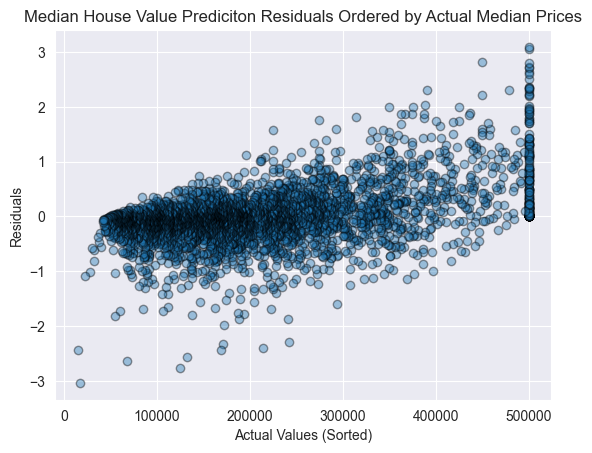

In [31]:
# Enter your code here

# Create a DataFrame to make sorting easy
residuals_df = pd.DataFrame({
    'Actual': 1e5*y_test,
    'Residuals': residuals #0에 가까울수록 좋음
})

# Sort the DataFrame by the actual target values
residuals_df = residuals_df.sort_values(by='Actual', ascending=False) # 실제 집값 기준으로 내림차순 정렬

# Plot the residuals
plt.scatter(residuals_df['Actual'], residuals_df['Residuals'] , marker='o', alpha=0.4,ec='k')
plt.title('Median House Value Prediciton Residuals Ordered by Actual Median Prices')
plt.xlabel('Actual Values (Sorted)')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


<details><summary>Click here for the solution</summary>
    
```python
    
# Create a DataFrame to make sorting easy
residuals_df = pd.DataFrame({
    'Actual': 1e5*y_test,
    'Residuals': residuals
})

# Sort the DataFrame by the actual target values
residuals_df = residuals_df.sort_values(by='Actual')

# Plot the residuals
plt.scatter(residuals_df['Actual'], residuals_df['Residuals'], marker='o', alpha=0.4,ec='k')
plt.title('Median House Value Prediciton Residuals Ordered by Actual Median Prices')
plt.xlabel('Actual Values (Sorted)')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()
```


### Exercise 6. What trend can you infer from this residual plot?

### 연습문제 6. 이 잔차 도표에서 어떤 추세를 추론할 수 있습니까?

In [ ]:
#### Please enter your descriptive answer here and change the cell type to "Markdown" for formatting.

#평균 잔차가 -1400달러로 작았지만, 이 그래프에서 볼 수 있듯이 중간 주택 가격에 따른 평균 오차는 실제로 음수에서 양수로 증가합니다.
#즉, 중간 가격이 낮을수록 과대 예측되는 경향이 있고, 중간 가격이 높을수록 과소 예측되는 경향이 있습니다.

<details><summary>Click here for the solution</summary>
Although we saw a small average residual of only -\$1400, you can see from this plot that the average error as a function of median house price is actually increasing from negative to positive values.
In other words, lower median prices tend to be overpredicted while higher median prices tend to be underpredicted.    
</details>


### Exercise 7. Display the feature importances as a bar chart.
Do you think these feature weights have practial significance? Are any of the features possibly sharing importance with other correlated features?

### 연습 7. 특징 중요도를 막대 그래프로 표시하세요.

이러한 특징 가중치가 실제적인 의미를 가진다고 생각하십니까? 상관관계가 있는 다른 특징들과 중요도를 공유하는 특징이 있습니까?

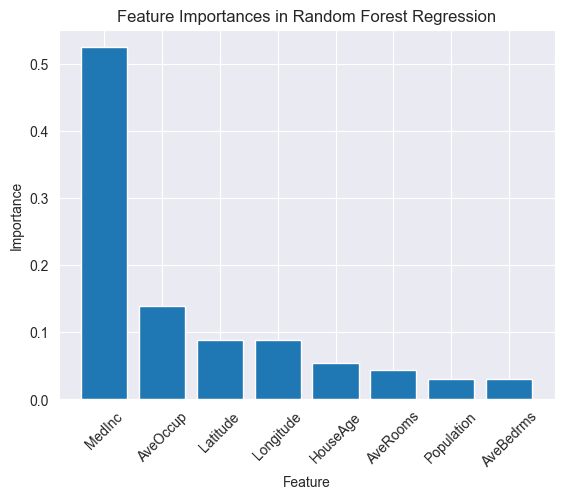

In [34]:
# Enter your code here 

# Feature importances
importances = rf_regressor.feature_importances_ # 각 특징의 중요도 점수 (0~1 범위, 합이 1)
indices = np.argsort(importances)[::-1] # argsort(): 중요도를 오름차순으로 정렬한 인덱스 # [::-1]: 역순 → 내림차순 (가장 중요한 것부터)
features = data.feature_names

# Plot feature importances
plt.bar(range(X.shape[1]), importances[indices],  align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")
plt.show()

In [ ]:
#### Please enter your descriptive answer here and change the cell type to "Markdown" for formatting.


<details><summary>Click here for the solution, part 1</summary>
    
```python
   
# Feature importances
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)[::-1]
features = data.feature_names

# Plot feature importances
plt.bar(range(X.shape[1]), importances[indices],  align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")
plt.show()
```


<details><summary>Click here for the solution, part 2</summary>
It makes sense that median incomes and house prices would be correlated, so it's not surprising that median income is the most important feature.

I would think that location must be a significant factor.

Since location is implied by two separate variables, latitude and longitude that share equal importances, we might speculate that location is really the second most important feature.
This is because replacing latitude and longitude with a categorical location at an appropriate level of granularity (suburb, city, etc.) would likely have a combined lat/lng importance, which might outweigh average occupancy.

Might average occupancy and average number of bedrooms be correlated?

A proper analysis of the feature set would include a correlation matrix.
</details>


### Exercise 8. Some final thoughts to consider

- Will the skewness affect the performance of Random Forest regression?
- Does the clipping of median house prices above \$500,000 bias the predictions?
- Also, do we need to standardize the data?

### 연습문제 8. 최종 고려 사항

- 왜곡도가 랜덤 포레스트 회귀의 성능에 영향을 미칠까요?

- 주택 중간값이 50만 달러 이상인 데이터를 잘라내는 것이 예측에 편향을 초래할까요?

- 또한, 데이터를 표준화해야 할까요?

In [ ]:
#### Please enter your descriptive answer here and change the cell type to "Markdown" for formatting.



<details><summary>Click here for the solution</summary>
Compared to linear regression, random forest regression is quite robust against outliers and skewed distributions.
This is because random forest regression doesn't make any assumptions about the data distribution, where linear regression performs best with normally distributed data.

Standardizing the data isn't necessary like it is for distance-based algortihms like KNN or SVMs.

Regarding the clipped vlaues, there is no variablilty in those values. Removing them in preprocessing might help the model to better explain the actual variance in the data. 

The clipped values can also bias the predictions.
Also these clipped values can mislead evaluation metrics. As you've learned from this lab, it's crucially important for you to visualize your results.

선형 회귀와 비교했을 때, 랜덤 포레스트 회귀는 이상치와 왜곡된 분포에 대해 상당히 강건합니다.

이는 랜덤 포레스트 회귀가 데이터 분포에 대한 가정을 하지 않기 때문입니다. 반면 선형 회귀는 정규 분포 데이터에서 최상의 성능을 보입니다.

KNN이나 SVM과 같은 거리 기반 알고리즘처럼 데이터를 표준화할 필요가 없습니다.

잘린 값에 관해서는, 해당 값들에는 변동성이 없습니다. 전처리 과정에서 이러한 값들을 제거하면 모델이 데이터의 실제 분산을 더 잘 설명하는 데 도움이 될 수 있습니다.

잘린 값은 예측에 편향을 초래할 수도 있습니다.

또한 이러한 잘린 값은 평가 지표를 왜곡할 수 있습니다. 이 실습에서 배웠듯이, 결과를 시각화하는 것이 매우 중요합니다.
</details>


## Summary
Congratulations! You're ready to move on to your next lesson! 
In this lab, you learned how to implement and assess the performance of random forest regression models using real-world data. You explored evaluation metrics and visualizations to understand the model's effectiveness and examined the feature importances in predicting outcomes. Using the California Housing dataset, you built a random forest regression model to predict median house prices based on various attributes, then evaluated and interpreted the results to understand the factors influencing the predictions.

## Author

<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>


### Other Contributors

<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" target="_blank">Abhishek Gagneja</a>

<!-- ## Changelog

| Date | Version | Changed by | Change Description |
|:------------|:------|:------------------|:---------------------------------------|
| 2024-11-12 | 1.0  | Jeff Grossman    | Create content |

 -->

## <h3 align="center"> © IBM Corporation. All rights reserved. <h3/>
